# Notebook 03 — Modélisation, comparaison de modèles & MLflow

#### Objectif
Construire des pipelines de classification pour prédire le défaut de paiement (TARGET),
comparer plusieurs modèles avec cross-validation, gérer le déséquilibre des classes,
et tracker toutes les expérimentations avec MLflow.

#### Modèles testés
- Logistic Regression (baseline linéaire)
- LightGBM (gradient boosting)
- XGBoost (gradient boosting)

#### Stratégie de gestion du déséquilibre
- Pondération des classes (`class_weight='balanced'` / `scale_pos_weight`)
- SMOTE (suréchantillonnage de la classe minoritaire)

#### Métriques
- AUC ROC (métrique principale — robuste au déséquilibre)
- Recall (sensibilité aux vrais positifs — important en contexte métier)
- F1-score

In [12]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, f1_score, make_scorer

import lightgbm as lgb
import xgboost as xgb
import mlflow
import mlflow.sklearn
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

sys.path.append('..')
from src.utils import reduce_memory

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

---
## 1. Chargement et préparation des données

In [3]:
# Charger les données enrichies
train = pd.read_csv('../data/processed/train_featured.csv')
train = reduce_memory(train)

print(f"Shape : {train.shape}")
print(f"TARGET : {train['TARGET'].value_counts(normalize=True).round(4) * 100}")

Mémoire : 624.3 Mo → 427.8 Mo (31% de réduction)
Shape : (307505, 147)
TARGET : TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [4]:
# Séparer X et y
y = train['TARGET']
X = train.drop(columns=['TARGET', 'SK_ID_CURR'])

# Identifier les colonnes par type
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

print(f"Features numériques : {len(num_cols)}")
print(f"Features catégorielles : {len(cat_cols)}")
print(f"\nCatégorielles : {cat_cols}")

Features numériques : 129
Features catégorielles : 16

Catégorielles : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


---
## 2. Setup MLflow & construction des pipelines

---
## 2. Setup MLflow & construction des pipelines

### Stratégie par modèle

Chaque algorithme a des besoins différents en prétraitement :

| Modèle | NaN | Catégorielles | Scaling |
|--------|-----|---------------|---------|
| Logistic Regression | Imputation obligatoire | OneHotEncoder | Oui (StandardScaler) |
| LightGBM | Natif | Type `category` | Non |
| XGBoost | Natif | `enable_categorical=True` | Non |

Avant de construire les pipelines, analysons le taux de NaN par colonne pour décider lesquelles conserver.

In [7]:
# Analyse du taux de NaN par colonne
nan_analysis = pd.DataFrame({
    'nan_count': X.isna().sum(),
    'nan_pct': (X.isna().sum() / len(X) * 100).round(2)
}).sort_values('nan_pct', ascending=False)

# Colonnes au-dessus de différents seuils
for threshold in [30, 50, 60, 70]:
    count = (nan_analysis['nan_pct'] > threshold).sum()
    print(f"Colonnes > {threshold}% NaN : {count}")

print("\n--- Colonnes avec plus de 50% de NaN ---")
high_nan = nan_analysis[nan_analysis['nan_pct'] > 50]
print(high_nan)

Colonnes > 30% NaN : 56
Colonnes > 50% NaN : 46
Colonnes > 60% NaN : 22
Colonnes > 70% NaN : 5

--- Colonnes avec plus de 50% de NaN ---
                           nan_count  nan_pct
PREV_CC_UTILIZATION_mean      230444    74.94
PREV_CC_DPD_DEF_max           229571    74.66
BUREAU_BB_STATUS_DPD_mean     215274    70.01
BUREAU_BB_STATUS_C_mean       215274    70.01
BUREAU_BB_STATUS_0_mean       215274    70.01
COMMONAREA_AVG                214861    69.87
COMMONAREA_MODE               214861    69.87
COMMONAREA_MEDI               214861    69.87
NONLIVINGAPARTMENTS_AVG       213511    69.43
NONLIVINGAPARTMENTS_MEDI      213511    69.43
NONLIVINGAPARTMENTS_MODE      213511    69.43
FONDKAPREMONT_MODE            210292    68.39
LIVINGAPARTMENTS_MODE         210196    68.36
LIVINGAPARTMENTS_AVG          210196    68.36
LIVINGAPARTMENTS_MEDI         210196    68.36
FLOORSMIN_MEDI                208639    67.85
FLOORSMIN_AVG                 208639    67.85
FLOORSMIN_MODE                20863

---
## 2. Setup MLflow & construction des pipelines

### Stratégie expérimentale

On compare 3 modèles avec **5 runs** au total :

| Run | Modèle | Traitement NaN | But |
|-----|--------|----------------|-----|
| 1 | Logistic Regression | Imputation médiane | Baseline linéaire |
| 2 | LightGBM | Imputation médiane | Comparaison équitable |
| 3 | XGBoost | Imputation médiane | Comparaison équitable |
| 4 | LightGBM | NaN natifs | Capacité réelle |
| 5 | XGBoost | NaN natifs | Capacité réelle |

### Gestion du déséquilibre (92/8)

Tous les modèles sont configurés dès le départ pour tenir compte du déséquilibre :

| Modèle | Paramètre | Effet |
|--------|-----------|-------|
| Logistic Regression | `class_weight='balanced'` | Pondère les erreurs selon la fréquence des classes |
| LightGBM | `is_unbalance=True` | Idem |
| XGBoost | `scale_pos_weight=11` | Ratio approximatif 92/8 |

Un run SMOTE sera ajouté sur le modèle gagnant pour comparer les stratégies de rééquilibrage.

In [8]:
# Initialiser MLflow
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("home-credit-default-risk")

print("MLflow configuré")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment : home-credit-default-risk")

2026/03/27 12:45:12 INFO mlflow.tracking.fluent: Experiment with name 'home-credit-default-risk' does not exist. Creating a new experiment.


MLflow configuré
Tracking URI : file:../mlruns
Experiment : home-credit-default-risk


### Construction des pipelines

**Deux configurations :**

| Config | Colonnes | Prétraitement | Utilisée par |
|--------|----------|---------------|--------------|
| A (équitable) | <60% NaN | Imputation + Scaling | Runs 1-2-3 |
| B (native) | Toutes | Conversion category uniquement | Runs 4-5 |

In [9]:
# Colonnes avec moins de 60% de NaN (config équitable)
cols_to_keep = nan_analysis[nan_analysis['nan_pct'] <= 60].index.tolist()

num_cols_eq = [c for c in num_cols if c in cols_to_keep]
cat_cols_eq = [c for c in cat_cols if c in cols_to_keep]

print(f"Config équitable (runs 1-2-3) :")
print(f"  Numériques : {len(num_cols_eq)}")
print(f"  Catégorielles : {len(cat_cols_eq)}")
print(f"  Total : {len(num_cols_eq) + len(cat_cols_eq)}")

print(f"\nConfig native (runs 4-5) :")
print(f"  Numériques : {len(num_cols)}")
print(f"  Catégorielles : {len(cat_cols)}")
print(f"  Total : {len(num_cols) + len(cat_cols)}")

Config équitable (runs 1-2-3) :
  Numériques : 108
  Catégorielles : 15
  Total : 123

Config native (runs 4-5) :
  Numériques : 129
  Catégorielles : 16
  Total : 145


In [10]:
# Preprocessor commun aux runs 1-2-3 (équitable)
# - Numériques : imputation médiane + standardisation
# - Catégorielles : imputation mode + one-hot encoding

preprocessor_eq = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_eq),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols_eq)
])

print("Preprocessor équitable créé")
print(f"  Numériques : imputation médiane + StandardScaler")
print(f"  Catégorielles : imputation mode + OneHotEncoder")

Preprocessor équitable créé
  Numériques : imputation médiane + StandardScaler
  Catégorielles : imputation mode + OneHotEncoder


In [13]:
# Run 1 : Logistic Regression
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_eq),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Run 2 : LightGBM (équitable)
pipeline_lgb_eq = Pipeline([
    ('preprocessor', preprocessor_eq),
    ('model', LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        verbose=-1  # silencieux
    ))
])

# Run 3 : XGBoost (équitable)
pipeline_xgb_eq = Pipeline([
    ('preprocessor', preprocessor_eq),
    ('model', XGBClassifier(
        scale_pos_weight=11,
        random_state=42,
        eval_metric='logloss'  
    ))
])

print("3 pipelines équitables créés :")
print("  - pipeline_lr (Logistic Regression)")
print("  - pipeline_lgb_eq (LightGBM)")
print("  - pipeline_xgb_eq (XGBoost)")

3 pipelines équitables créés :
  - pipeline_lr (Logistic Regression)
  - pipeline_lgb_eq (LightGBM)
  - pipeline_xgb_eq (XGBoost)


In [14]:
# Pour les runs 4-5, on garde toutes les colonnes
# On convertit juste les catégorielles en type 'category' pour LightGBM/XGBoost

X_native = X.copy()
for col in cat_cols:
    X_native[col] = X_native[col].astype('category')

print("Dataset natif préparé")
print(f"  Shape : {X_native.shape}")
print(f"  Colonnes category : {len(cat_cols)}")
print(f"  NaN conservés : oui")

Dataset natif préparé
  Shape : (307505, 145)
  Colonnes category : 16
  NaN conservés : oui


In [15]:
# Run 4 : LightGBM natif
model_lgb_native = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    verbose=-1
)

# Run 5 : XGBoost natif
model_xgb_native = XGBClassifier(
    scale_pos_weight=11,
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True  
)

print("2 modèles natifs créés :")
print("  - model_lgb_native (LightGBM)")
print("  - model_xgb_native (XGBoost)")

2 modèles natifs créés :
  - model_lgb_native (LightGBM)
  - model_xgb_native (XGBoost)


---
## 3. Cross-validation et tracking MLflow

### Métriques choisies

Pour un problème de crédit avec déséquilibre 92/8, on s'intéresse à :

| Métrique |  |
|----------|----------|
| **ROC-AUC** | Performance globale, insensible au seuil |
| **Recall** | Capacité à détecter les défauts (classe 1) — critique pour le métier |
| **F1-score** | Équilibre précision/recall |

### Protocole

- Cross-validation stratifiée à 5 folds (préserve le ratio 92/8 dans chaque fold)
- Chaque run est loggé dans MLflow avec ses paramètres et métriques

In [16]:
# Cross-validation stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métriques à calculer
scoring = {
    'auc': 'roc_auc',
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

print("Cross-validation configurée : 5 folds stratifiés")
print("Métriques : AUC, Recall, F1")

Cross-validation configurée : 5 folds stratifiés
Métriques : AUC, Recall, F1


In [18]:
def run_experiment(run_name, model, X_data, y_data, params_to_log, tags=None):
    """
    Exécute une cross-validation et log les résultats dans MLflow.
    
    Arguments:
        run_name : nom du run dans MLflow
        model : pipeline ou modèle à évaluer
        X_data : features
        y_data : target
        params_to_log : dict des paramètres à logger
        tags : dict des tags à ajouter 
    """
    
    with mlflow.start_run(run_name=run_name):
        
        # Logger les tags
        if tags:
            for key, value in tags.items():
                mlflow.set_tag(key, value)
        
        # 1. Logger les paramètres
        for key, value in params_to_log.items():
            mlflow.log_param(key, value)
        
        # 2. Cross-validation
        print(f"Running {run_name}...")
        cv_results = cross_validate(
            model, X_data, y_data,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )
        
        # 3. Calculer les moyennes
        metrics = {
            'AUC': cv_results['test_auc'].mean(),
            'AUC_std': cv_results['test_auc'].std(),
            'Recall': cv_results['test_recall'].mean(),
            'Recall_std': cv_results['test_recall'].std(),
            'F1': cv_results['test_f1'].mean(),
            'F1_std': cv_results['test_f1'].std()
        }
        
        # 4. Logger les métriques dans MLflow
        mlflow.log_metric("AUC_mean", metrics['AUC'])
        mlflow.log_metric("AUC_std", metrics['AUC_std'])
        mlflow.log_metric("Recall_mean", metrics['Recall'])
        mlflow.log_metric("Recall_std", metrics['Recall_std'])
        mlflow.log_metric("F1_mean", metrics['F1'])
        mlflow.log_metric("F1_std", metrics['F1_std'])
        
        # 5. Afficher les résultats
        print(f"  AUC:    {metrics['AUC']:.4f} (+/- {metrics['AUC_std']:.4f})")
        print(f"  Recall: {metrics['Recall']:.4f} (+/- {metrics['Recall_std']:.4f})")
        print(f"  F1:     {metrics['F1']:.4f} (+/- {metrics['F1_std']:.4f})")
        print()
        
        return metrics

print("Fonction run_experiment() créée")

Fonction run_experiment() créée


In [19]:
# Tags communs à tous les runs
tags_phase1 = {
    'phase': 'comparaison_initiale',
    'author': 'Fatih',
    'dataset': 'home_credit'
}

# Stockage des résultats
results = {}

# Run 1 : Logistic Regression
results['LogReg'] = run_experiment(
    run_name="01_LogReg_equitable",
    model=pipeline_lr,
    X_data=X[num_cols_eq + cat_cols_eq],
    y_data=y,
    params_to_log={
        'model': 'LogisticRegression',
        'nan_strategy': 'imputation_median',
        'class_balance': 'balanced',
        'n_features': len(num_cols_eq) + len(cat_cols_eq)
    },
    tags=tags_phase1
)

# Run 2 : LightGBM équitable
results['LightGBM_eq'] = run_experiment(
    run_name="02_LightGBM_equitable",
    model=pipeline_lgb_eq,
    X_data=X[num_cols_eq + cat_cols_eq],
    y_data=y,
    params_to_log={
        'model': 'LightGBM',
        'nan_strategy': 'imputation_median',
        'class_balance': 'is_unbalance=True',
        'n_features': len(num_cols_eq) + len(cat_cols_eq)
    },
    tags=tags_phase1
)

# Run 3 : XGBoost équitable
results['XGBoost_eq'] = run_experiment(
    run_name="03_XGBoost_equitable",
    model=pipeline_xgb_eq,
    X_data=X[num_cols_eq + cat_cols_eq],
    y_data=y,
    params_to_log={
        'model': 'XGBoost',
        'nan_strategy': 'imputation_median',
        'class_balance': 'scale_pos_weight=11',
        'n_features': len(num_cols_eq) + len(cat_cols_eq)
    },
    tags=tags_phase1
)

print("Runs équitables (1-2-3) terminés")

Running 01_LogReg_equitable...
  AUC:    0.7546 (+/- 0.0045)
  Recall: 0.6856 (+/- 0.0056)
  F1:     0.2659 (+/- 0.0023)

Running 02_LightGBM_equitable...
  AUC:    0.7677 (+/- 0.0028)
  Recall: 0.6899 (+/- 0.0036)
  F1:     0.2752 (+/- 0.0016)

Running 03_XGBoost_equitable...
  AUC:    0.7553 (+/- 0.0022)
  Recall: 0.6070 (+/- 0.0052)
  F1:     0.2828 (+/- 0.0018)

Runs équitables (1-2-3) terminés


In [20]:
# Run 4 : LightGBM natif
results['LightGBM_native'] = run_experiment(
    run_name="04_LightGBM_native",
    model=model_lgb_native,
    X_data=X_native,
    y_data=y,
    params_to_log={
        'model': 'LightGBM',
        'nan_strategy': 'native',
        'class_balance': 'is_unbalance=True',
        'n_features': len(num_cols) + len(cat_cols)
    },
    tags=tags_phase1
)

# Run 5 : XGBoost natif
results['XGBoost_native'] = run_experiment(
    run_name="05_XGBoost_native",
    model=model_xgb_native,
    X_data=X_native,
    y_data=y,
    params_to_log={
        'model': 'XGBoost',
        'nan_strategy': 'native',
        'class_balance': 'scale_pos_weight=11',
        'n_features': len(num_cols) + len(cat_cols)
    },
    tags=tags_phase1
)

print("Runs natifs (4-5) terminés")

Running 04_LightGBM_native...
  AUC:    0.7699 (+/- 0.0031)
  Recall: 0.6858 (+/- 0.0068)
  F1:     0.2804 (+/- 0.0021)

Running 05_XGBoost_native...
  AUC:    0.7499 (+/- 0.0034)
  Recall: 0.5781 (+/- 0.0072)
  F1:     0.2866 (+/- 0.0028)

Runs natifs (4-5) terminés


---
## Observations et conclusions des 5 runs

### Tableau récapitulatif

| Run | Modèle | Config | Features | AUC | Recall | F1 |
|-----|--------|--------|----------|-----|--------|-----|
| 1 | Logistic Regression | équitable | 123 | 0.7546 | 0.6856 | 0.2659 |
| 2 | LightGBM | équitable | 123 | 0.7677 | 0.6899 | 0.2752 |
| 3 | XGBoost | équitable | 123 | 0.7553 | 0.6070 | 0.2828 |
| 4 | LightGBM | native | 145 | **0.7699** | 0.6858 | 0.2804 |
| 5 | XGBoost | native | 145 | 0.7499 | 0.5781 | 0.2866 |

### Observations

- **LightGBM domine** sur l'AUC et le Recall dans les deux configurations
- **Gestion native des NaN** : gain marginal pour LightGBM, dégradation pour XGBoost
- **F1 faible** (~0.27) pour tous les modèles, normal avec un déséquilibre 92/8, le Recall élevé génère des faux positifs

### Conclusion

**Modèle retenu pour l'optimisation : LightGBM natif (run 4)**

Meilleur AUC (0.7699), bon Recall (0.6858), et utilise les données réelles sans imputation artificielle.

---
## 4. Feature importance

On analyse les features les plus importantes du modèle LightGBM natif (run 4), notre meilleur modèle.

In [21]:
# Entraîner LightGBM natif sur tout le dataset pour extraire la feature importance
model_lgb_native.fit(X_native, y)

# Récupérer l'importance
feature_importance = pd.DataFrame({
    'feature': X_native.columns,
    'importance': model_lgb_native.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes :")
print(feature_importance.head(20).to_string(index=False))

Top 20 features les plus importantes :
                   feature  importance
         ORGANIZATION_TYPE         682
              EXT_SOURCE_1         145
              EXT_SOURCE_2         115
                AMT_CREDIT         113
              EXT_SOURCE_3         105
           OCCUPATION_TYPE          91
               AMT_ANNUITY          84
  PREV_CC_UTILIZATION_mean          75
             DAYS_EMPLOYED          72
                DAYS_BIRTH          70
           AMT_GOODS_PRICE          70
      BUREAU_AMT_DEBT_mean          59
               OWN_CAR_AGE          53
PREV_INS_PAYMENT_DIFF_mean          52
    DAYS_LAST_PHONE_CHANGE          51
      PREV_AMT_CREDIT_mean          50
           DAYS_ID_PUBLISH          50
   BUREAU_DAYS_CREDIT_mean          49
BUREAU_AMT_CREDIT_SUM_mean          49
BUREAU_AMT_MAX_OVERDUE_max          48


In [24]:
from sklearn.inspection import permutation_importance

# Permutation importance (plus fiable pour les catégorielles à haute cardinalité)
perm_result = permutation_importance(
    model_lgb_native, X_native, y, 
    n_repeats=5, 
    scoring='roc_auc', 
    random_state=42
)

perm_importance = pd.DataFrame({
    'feature': X_native.columns,
    'importance_mean': perm_result.importances_mean
}).sort_values('importance_mean', ascending=False)

print("Top 20 features (permutation importance) :")
print(perm_importance.head(20).to_string(index=False))

Top 20 features (permutation importance) :
                   feature  importance_mean
              EXT_SOURCE_2         0.041310
              EXT_SOURCE_3         0.039321
         ORGANIZATION_TYPE         0.022419
              EXT_SOURCE_1         0.017330
                AMT_CREDIT         0.014088
           AMT_GOODS_PRICE         0.011343
  PREV_CC_UTILIZATION_mean         0.006904
               AMT_ANNUITY         0.006787
                DAYS_BIRTH         0.006760
      BUREAU_AMT_DEBT_mean         0.006283
             DAYS_EMPLOYED         0.005682
               OWN_CAR_AGE         0.005552
               CODE_GENDER         0.005447
        PREV_REFUSED_COUNT         0.004309
       NAME_EDUCATION_TYPE         0.003852
PREV_INS_PAYMENT_DIFF_mean         0.003720
    DAYS_LAST_PHONE_CHANGE         0.003481
           OCCUPATION_TYPE         0.003421
           DAYS_ID_PUBLISH         0.003184
BUREAU_AMT_MAX_OVERDUE_max         0.003068


### Comparaison des deux méthodes de feature importance

| Méthode | Principe | Biais |
|---------|----------|-------|
| Importance par défaut (split) | Nombre de fois qu'une feature est utilisée pour splitter | Favorise les variables à beaucoup de modalités |
| Permutation importance | Baisse de performance quand on mélange les valeurs | Plus fiable, indépendante du type de variable |

**Constat** : `ORGANIZATION_TYPE` passe du rang 1 (split importance) au rang 3 (permutation importance). Son score par défaut était gonflé par ses ~58 modalités. Les `EXT_SOURCE` sont confirmées comme les vraies top features prédictives.

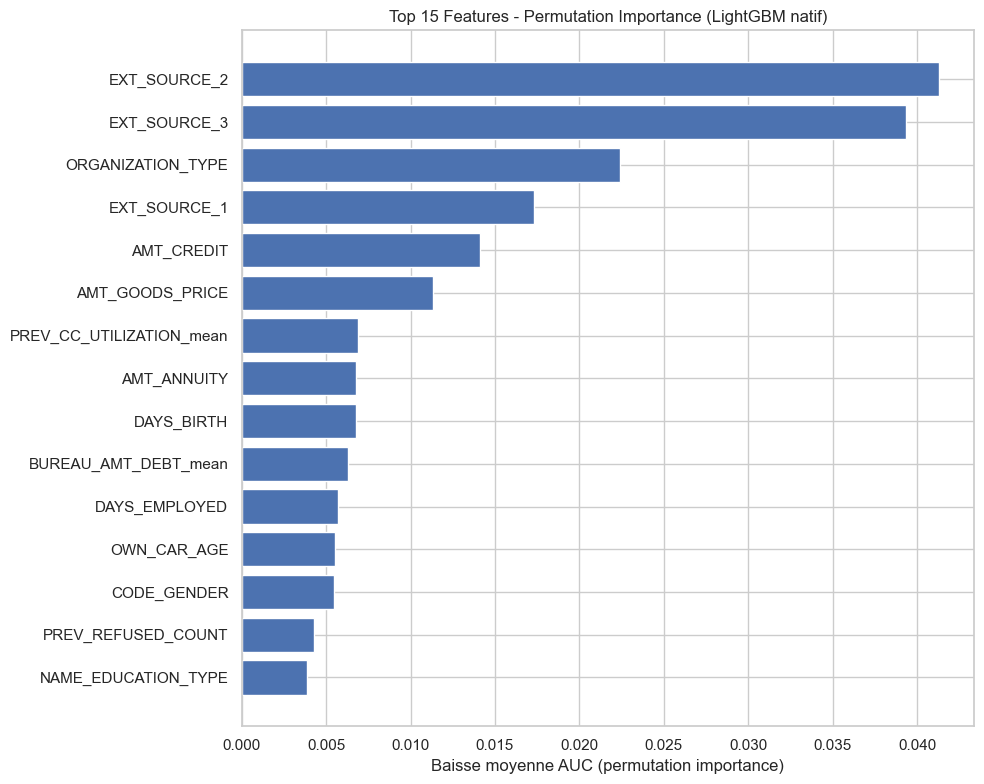

In [25]:
# Visualisation côte à côte : top 15 permutation importance
plt.figure(figsize=(10, 8))
top_15 = perm_importance.head(15)
plt.barh(top_15['feature'], top_15['importance_mean'])
plt.gca().invert_yaxis()
plt.xlabel('Baisse moyenne AUC (permutation importance)')
plt.title('Top 15 Features - Permutation Importance (LightGBM natif)')
plt.tight_layout()
plt.show()

---
## 5. Test SMOTE sur le modèle gagnant

SMOTE (Synthetic Minority Over-sampling Technique) crée des exemples synthétiques 
de la classe minoritaire en interpolant entre voisins proches.

On compare pondération vs SMOTE sur LightGBM avec le même dataset (équitable) :
- Run 2 : LightGBM + pondération (`is_unbalance=True`)
- Run 6 : LightGBM + SMOTE (sans pondération)

In [22]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline LightGBM + SMOTE
# On utilise imblearn.Pipeline pour le SMOTE

pipeline_lgb_smote = ImbPipeline([
    ('preprocessor', preprocessor_eq),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(
        random_state=42,
        verbose=-1
    ))
])

print("Pipeline LightGBM + SMOTE créé")

Pipeline LightGBM + SMOTE créé


In [23]:
# Run 6 : LightGBM SMOTE
results['LightGBM_SMOTE'] = run_experiment(
    run_name="06_LightGBM_SMOTE",
    model=pipeline_lgb_smote,
    X_data=X[num_cols_eq + cat_cols_eq],
    y_data=y,
    params_to_log={
        'model': 'LightGBM',
        'nan_strategy': 'imputation_median',
        'class_balance': 'SMOTE',
        'n_features': len(num_cols_eq) + len(cat_cols_eq)
    },
    tags={
        'phase': 'comparaison_initiale',
        'author': 'Fatih',
        'dataset': 'home_credit',
        'comparison': 'SMOTE_vs_ponderation'
    }
)

Running 06_LightGBM_SMOTE...
  AUC:    0.7583 (+/- 0.0036)
  Recall: 0.0190 (+/- 0.0007)
  F1:     0.0367 (+/- 0.0013)



### Comparaison pondération vs SMOTE (LightGBM équitable)

| Stratégie | AUC | Recall | F1 |
|-----------|-----|--------|-----|
| Pondération (`is_unbalance=True`) | 0.7677 | 0.6899 | 0.2752 |
| SMOTE | 0.7583 | 0.0190 | 0.0367 |

**SMOTE dégrade fortement les performances.** Le Recall tombe à 1.9% — le modèle ne détecte presque plus aucun défaut. La pondération des classes est nettement plus efficace ici.

**Conclusion** : la pondération (`is_unbalance`, `class_weight='balanced'`) est la stratégie retenue pour la gestion du déséquilibre.

In [26]:
# Enregistrer le modèle dans MLflow
with mlflow.start_run(run_name="best_model_LightGBM_native"):
    
    mlflow.log_param("model", "LightGBM")
    mlflow.log_param("nan_strategy", "native")
    mlflow.log_param("class_balance", "is_unbalance=True")
    mlflow.log_param("n_features", len(num_cols) + len(cat_cols))
    
    mlflow.log_metric("AUC_mean", results['LightGBM_native']['AUC'])
    mlflow.log_metric("Recall_mean", results['LightGBM_native']['Recall'])
    mlflow.log_metric("F1_mean", results['LightGBM_native']['F1'])
    
    mlflow.set_tag("phase", "model_registry")
    mlflow.set_tag("author", "Fatih")
    mlflow.set_tag("status", "best_model")
    
    mlflow.sklearn.log_model(
        model_lgb_native,
        artifact_path="model",
        registered_model_name="home-credit-lightgbm"
    )
    
    print("Modèle enregistré dans le registry : home-credit-lightgbm")

2026/03/29 15:51:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 15:51:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modèle enregistré dans le registry : home-credit-lightgbm


Successfully registered model 'home-credit-lightgbm'.
Created version '1' of model 'home-credit-lightgbm'.


---
## Conclusion du notebook 03

### Ce qui a été fait
- 6 runs MLflow comparant 3 modèles (LogReg, LightGBM, XGBoost)
- Comparaison équitable (même dataset) et native (NaN gérés nativement)
- Pondération vs SMOTE pour la gestion du déséquilibre
- Feature importance (split + permutation)
- Modèle enregistré dans le model registry MLflow

### Modèle retenu : LightGBM natif
- AUC : 0.7699 | Recall : 0.6858 | F1 : 0.2804
- Gestion native des NaN (pas d'imputation artificielle)
- SMOTE contre-productif, pondération retenue

### Prochaine étape : Notebook 04
- Optimisation des hyperparamètres (Optuna)
- Fonction de coût métier (FN coûte 10× plus que FP)
- Optimisation du seuil de décision